ESERCIZIO PRATICO: GENERARE CIFRE CON SVHN CON DCGAN

Passiamo dalle cifre scritte a mano ai numeri catturate da telecamere.
Non stiamo solo imparando a copiare ma ad estrarre l'essenza visiva da contesti urbani rumorosi.

- Pipeline Dati SVHN: Gestione RGB e Immagini Naturali
- Refactorin Convoluzionale: upsampling e Stride
- Monitoraggio Visivo: separare il segnale dallo sfondo.

Perchè 3 cancali coloro sono molto più difficili di 1

Il dataset SVHM (Street View House Numbers) rappresenta il passaggio logico successivo a MNIST.
Mentre in MNIST è binarizzato e pulito, SVHN contiene cifre reali ritagliate da contesti urbani.
Abbiamo mattoni, ombre riflessi che fanno capolino tra i bordi.
Lavorare con SVHN ci costringe ad affrontare la tridimensionalità del colore e la variabilità dell'illuminazione, rendendo il compito del generatore significativamente più complesso.
Lavorare ocn SVHN significa dire alla GAN di non imparare solo la forma di un 7 ma imparare come la luce colpisce il 7 su un pezzi di metallo in una strada di San Francesco.

Gestione dei Tensori RGB
passiamo da una griglia piatta ad un volume informativo.
La normalizzazione diventa vitale, è come l'accordatura di uno strumento, se i canali RGB non sono calibrati tra loro, il generatore produrrà immagini con dominanti cromatiche orribili. Poliziotto e falsario devono parlare la stessa lingua statistica.
Praparare il dataset per la DCGAN
- Caricamento tramite torchvision.datasets.SVHN specificando lo split 'train' o 'test'
- Passaggio alla forma (3,32,32) che triplica il numero di canali rispetto a MNIST.
- Normalizzazione centrata su zero con media e deviazione standard 0.5 per ogni canale.
- L'input della rete non è più un piano bidimensionale ma un volume informativo RGB

Ma oltre al colore dobbiamo fare i conti con l'imprevedibilità del mondo esterno.

Dinamiche del Dataset SVHN
A differenza del MNIST, qui i pixel di sfondo contengono rumore reale: cartelli stradali, ombre e riflessi (immagini Naturali).
Le cifre sono centrate ma la loro forma varia enormemente a causa delle diverse font e angolazioni di ripresa (allineamento spaziale). Sono distore, hanno angolazioni diverse e sfondi che cambiano continuamente. Questo aumenta il costo computazionale per distinguere quello che è un numero e quello che è rumore visivo. Il modello deve imparare una gerarchia visiva, molto più profonda, per non farsi ingannare per esempio dalle ombre.
L'aumento di risoluzione a 32x32 richiede un numero maggiore di filtri er catturare i dettagli strutturali del colore (costo computazionale).

Per aiutare la rete, dobbiamo scegliere con cura il suo respiro Matematico.

L'Importanza della Normalizzazione.
Range [-1,1] e Tanh
Il Generatore usa la funzione Tanh nell'ultimo strato.
Immaginala come una membrana elastica che puòò oscillare simmetricamente attorno allo zero.
Se non mappiamo i dati reali nello stesso modo, la rete passerà metà del tempo a capire perchè i conti non tornano.
Utilizziamo una normalizzazione che mappa i pixel nell'intervallo -1,1 per essere coerenti con l'attivazione Tanh del Generatore.
Questo bilanciamento previene la saturazione precoce dei neuroni e facilita la convergenza del gradiente durante la sfida avversaria.

E ora che i dati sono pronti, costruiamo i muscoli della nostra architettura.

Refactoring in Deep Convolutional
Dal MLP ai blocchi convoluzionali puri.
Abbandoniamo definitivamente gli strati 'Linear' (layer Dense) per abbracciare un'architettura che rispetta la topologia delle immagini.
Nella immagini naturali la posizione conta, un pixel rosso in alto a sinistra non è uguale ad un pixel rosso al centro.
Il refactoring consiste nell usare blocchi convoluzionali che rispettano la topologia
Il refactoring si concentra sulla costruzione di un Generatore che espande lo spazio latente e di un Discriminatore che comprime i volti RGB.

Upsampling e Downsampling
Meccaniche di trasformazione spaziale
- Uso di nn.ConvTranspose2d per raddoppiare la risoluzione spaziale in ogni layer del Generatore.
Se la convoluzione normale è un riassunto la trasposta è un espansione. Prendiamo un punto e lo espandiamo su un'area più grande. Non stiamo solo ingrandendo pixel, ma stiamo addestrando la rete di decidere come riempire i nuovi spazi tra essi.
- Il Discriminatore utilizza nn.Conv2d con stride 2 al posto dei layer di pooling per mantenere i gradineti sani.
- I filtri partono da 512 nel collo di bottiglia e si riducono a 3 (RGB) nell'output finale del Generatore.
- L'azzenza di layer lineari riduce drasticamente il numero di parametri pur aumentando la capacità espressiva.

Componenti del Refactoring
La Batch Normalization è necessaria dopo ogni convoluzione per stabilizzare la distribuzione dei dati all'interno del mini-batch. Agice come un moderatore durante un dibattito acceso, impedendo che un singolo layer urli troppo forte destasbilizzando tutto il processo di apprendimento.
La LeakyReLU nel Discriminatore è fondamentale per permettere al gradiente di fluire anche quando la rete sta scartando immagini false. PErmette di imparare anche da un piccolo errore, lasciando passare il segnale quando l'immagine sembra falsa. Senza di lei il poliziotto diventerebbe muto troppo presto.
Lo Zero Padding Strategico permette di controllare con precisione che la risoluzine finale sia esattamente 32x32 pixel

Ma come trasformiamo un singolo vettore di 100 numeri in un volume 3D

Progettare il Collo di Bottiglia
Dal vettore 100x1 al volume 512x4x4
Il primo layer del Generatore deve proiettare il rumore z in un volume 4D che la convoluzione possa processare e capire.
Questa transizione tra spazio latente e spazio geometrico è il momento in cui nasce la struttura dell'immagine.
E' come se il generatore prendesse 100 idee e le disponesse su un tavolo 4x4 decidendo dove vanno le ombre e dove i contorni.
Da questo piccolo seme nascerà l'immagine 32x32

Come capiamo se sta funzionando realmente?
Nelle GAN la funzionione di perdita (loss) NON è un indicatore affidabile di qualità. Dobbiamo implementare sistemi di monitoraggio visivo costanti.
Il monitoraggio visivo costante è l'unico modo per fare vera diagnostica in questo campo.

Per farlo in modo sistemico useremo il rumore fisso.
- Creazione di un vettore di rumore fisso per generare sempre gli stessi semi di immagini durante il training.
- Utilizzo di vutils.save_image per produrre griglie di campioni comparabili tra diverse epoche.
- Osservazione del passaggio dal rumore incoerente a forme geometriche semplici e infine a cifre realistiche.
- La separazione tra cifra e sfondo urbano è l'indicatore principale della maturità del modello.
Noteremo il rumore che si trasforma prima in macchie di colore, poi forme vaghe e infine in numeri civici con texture realistiche.
La separazione tra cifre e sfondo è il nostro segnale di vittoria.

Ma cosa vedremo in queste ore di addestramento?
(minuti se diminuiamo le epoche)
L'evoluzione segue un ordine preciso. La rete impara prima a riprodurre le palette di colori del dataset e solo successivamente i bordi delle cifre (separazione del Segnale).
E' affascinante osservare come G tenti di imitare anche le interferenze esterne come i disturbi dello sfondo (artefatti urbani).
Se le griglie iniziano a diventare sbiadite o ripetitive, è il segnale di un collasso imminnete o di un overfitting del discriminatore.

Interpretare la Loss vs Immagine
Il paradosso del realismo
A volte la loss di G aumenta mentre le immagini diventano visibilmente migliori: il Discriminatore sta diventando un critico più sofisticato
Questa analisi ci insegna a non disperare davanti a grafici oscillanti se la rese visiva è in crescita.
La qualità nella GAN è un giudizion estetico supportato dalla matematica.

100%|██████████| 182M/182M [01:05<00:00, 2.79MB/s] 


Addestramento iniziato su cpu...


Epoch [10/10]: 100%|██████████| 573/573 [07:26<00:00,  1.28it/s, D_loss=1.44, G_loss=0.853] 


Addestramento completato!
Mostrando i risultati a video...


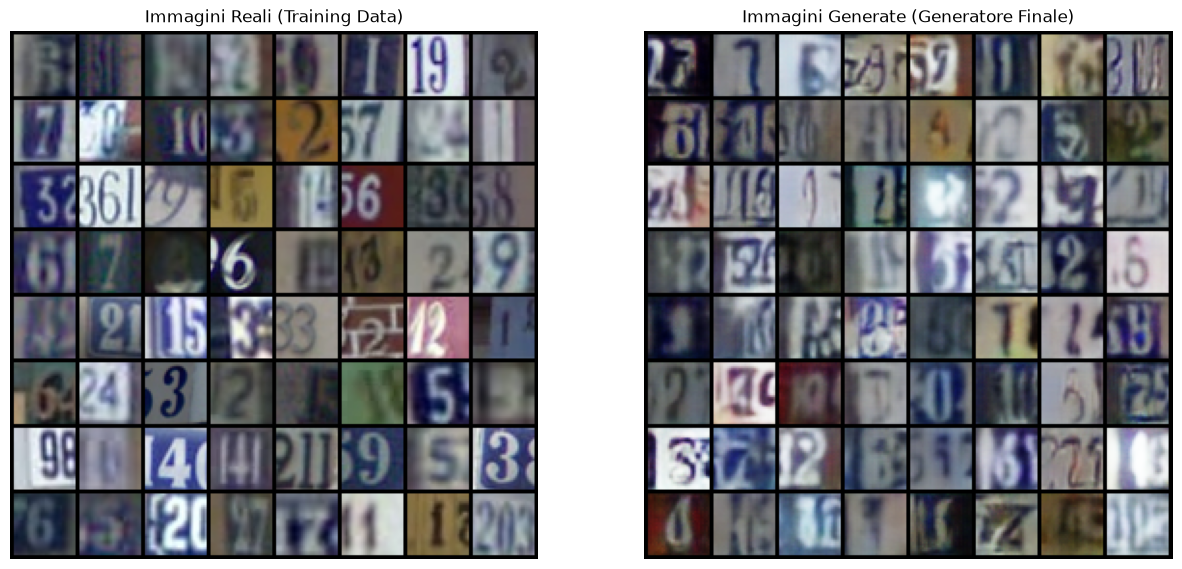

In [1]:
# Import delle librerie necessarie
import torch
from torch import nn, optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURAZIONE E IPERPARAMETRI ---
# Definiamo il dispositivo di calcolo (GPU se disponibile, altrimenti CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dimensione del vettore latente (input del generatore). E' il "seme" casuale da cui nasce l'immagine.
latent_dim = 100

# Iperparametri di addestramento
lr = 0.0002       # Learning rate (basso per stabilizzare le GAN)
beta1 = 0.5       # Parametro beta1 per l'ottimizzatore Adam (consigliato 0.5 dal paper DCGAN)
epochs = 10       # Numero di passaggi completi sul dataset

# Definizione delle trasformazioni per le immagini di input
transform = transforms.Compose([
    transforms.Resize(32),  # Ridimensioniamo tutto a 32x32 pixel
    transforms.ToTensor(),  # Convertiamo l'immagine in un tensore PyTorch (valori 0-1)
    # Normalizzazione: porta i valori da [0, 1] a [-1, 1].
    # Questo e' fondamentale perche' il Generatore usa Tanh come attivazione finale, producendo valori in [-1, 1].
    # La formula e': output = (input - mean) / std -> (input - 0.5) / 0.5
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Caricamento del dataset SVHN (Street View House Numbers)
train_data = datasets.SVHN(root='.', split='train', download=True, transform=transform)

# DataLoader gestisce il caricamento in batch e il mescolamento dei dati
dataloader = DataLoader(train_data, batch_size=128, shuffle=True)

# --- 2. DEFINIZIONE DELL'ARCHITETTURA ---

# Funzione per inizializzare i pesi della rete.
# Nelle GAN profonde (DCGAN), inizializzare i pesi con una distribuzione normale
# media 0 e deviazione standard 0.02 aiuta la convergenza (best practice dal paper).
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# CLASSE GENERATORE
# Scopo: Trasformare un vettore di rumore casuale (latent_dim) in un'immagine RGB 32x32.
# Funzionamento: Usa ConvTranspose2d (convoluzioni trasposte o "deconvoluzioni") per fare upsampling.
# Parte da un tensore piccolo ma profondo (tanti canali) ed espande le dimensioni spaziali riducendo i canali.
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Input: vettore latente Z (es. 100 x 1 x 1)
            # ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding)
            
            # Layer 1: Espansione iniziale
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), 
            nn.ReLU(True), # ReLU aiuta ad apprendere non-linearità complesse
            
            # Layer 2: Upsampling intermedio
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), 
            nn.ReLU(True),
            
            # Layer 3: Upsampling intermedio
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), 
            nn.ReLU(True),
            
            # Layer 4: Output finale verso l'immagine
            # Output: 3 canali (RGB), Kernel 4, Stride 2 -> Immagine 32x32
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            
            # Tanh comprime l'output in [-1, 1], corrispondente al range delle immagini normalizzate
            nn.Tanh()
        )
    def forward(self, x): return self.main(x)

# CLASSE DISCRIMINATORE
# Scopo: Classificatore binario che prende un'immagine (3x32x32) e restituisce una probabilità.
# Output: Probabilità che l'immagine sia REALE (vicino a 1) o FALSA/GENERATA (vicino a 0).
# Funzionamento: Usa Conv2d standard per ridurre la dimensione spaziale ed estrarre feature (downsampling).
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Layer 1: Input immagine RGB 3x32x32
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=False), # LeakyReLU è preferito nelle GAN per evitare gradienti nulli
            
            # Layer 2: Estrazione feature
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), 
            nn.LeakyReLU(0.2, inplace=False),
            
            # Layer 3: Estrazione feature
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), 
            nn.LeakyReLU(0.2, inplace=False),
            
            # Layer 4: Output singolo scalare (probabilità)
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            
            # Sigmoid schiaccia l'output in [0, 1] per interpretarlo come probabilità
            nn.Sigmoid()
        )
    # .view(-1, 1) assicura che l'output sia un vettore colonna (Batch_Size, 1) compatibile con la loss
    def forward(self, x): return self.main(x).view(-1, 1)

# Inizializzazione delle reti e applicazione dei pesi custom
netG = Generator().to(device).apply(weights_init)
netD = Discriminator().to(device).apply(weights_init)

# Funzione di costo: Binary Cross Entropy Loss
# E' la loss standard per problemi di classificazione binaria (Vero/Falso).
criterion = nn.BCELoss()

# Ottimizzatori Adam per entrambe le reti
optD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Vettore di rumore "fisso" per monitorare i progressi.
# Generando immagini sempre dallo stesso seme casuale, possiamo vedere oggettivamente
# come cambia la capacita' del generatore durante le epoche.
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

# Creazione cartella per salvare i campioni generati
os.makedirs("samples", exist_ok=True)

# --- 3. CICLO DI ADDESTRAMENTO ---
print(f"Addestramento iniziato su {device}...")

for epoch in range(epochs):
    # Utilizziamo tqdm per avere una barra di avanzamento visiva durante l'epoca
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), leave=True)
    
    for i, (real_imgs, _) in progress_bar:
        # Dimensione del batch corrente (potrebbe essere minore di 128 nell'ultimo batch)
        b_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        
        # ==================================================================
        # FASE 1: ADDESTRAMENTO DEL DISCRIMINATORE (netD)
        # Obiettivo: Massimizzare log(D(x)) + log(1 - D(G(z)))
        # Deve riconoscere le immagini vere come VERE e quelle generate come FALSE.
        # ==================================================================
        
        netD.zero_grad() # Pulizia gradienti precedenti
        
        # 1.1 Addestramento con immagini REALI
        # Creiamo un tensore di etichette "Reali". Usiamo 0.9 invece di 1.0 (Label Smoothing)
        # per evitare che il discriminatore diventi troppo sicuro di se' troppo in fretta.
        label_real = torch.full((b_size, 1), 0.9, device=device)
        output_real = netD(real_imgs)
        lossD_real = criterion(output_real, label_real) # Calcolo errore sulle reali
        
        # 1.2 Addestramento con immagini FALSE (Generate)
        # Generiamo rumore casuale
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        # Il generatore crea immagini false partendo dal rumore
        fake_imgs = netG(noise)
        # Etichetta "Falso" e' 0
        label_fake = torch.zeros((b_size, 1), device=device)
        # .detach() e' CRUCIALE qui: scollega il grafo computazionale del Generatore.
        # Quando calcoliamo la loss del Discriminatore, non vogliamo modificare i pesi del Generatore,
        # quindi "stacchiamo" le immagini false dalla storia che le ha generate.
        output_fake = netD(fake_imgs.detach()) 
        lossD_fake = criterion(output_fake, label_fake) # Calcolo errore sulle false
        
        # Aggiornamento pesi Discriminatore
        lossD = lossD_real + lossD_fake # Errore totale
        lossD.backward()
        optD.step()

        # ==================================================================
        # FASE 2: ADDESTRAMENTO DEL GENERATORE (netG)
        # Obiettivo: Massimizzare log(D(G(z)))
        # Il Generatore vuole ingannare il Discriminatore, facendogli credere che
        # le immagini generate siano vere (Label = 1).
        # ==================================================================
        
        netG.zero_grad()
        
        # Passiamo di nuovo le immagini false al discriminatore (senza detach()...)
        # perche' ora vogliamo che il gradiente fluisca all'indietro fino al generatore.
        output_g = netD(fake_imgs)
        
        # Il TRUCCO: calcoliamo la loss confrontando le immagini generate con l'etichetta REALE (1).
        # Se il discriminatore dice "Falso" (0), la loss sara' alta -> il Generatore impara a correggersi.
        lossG = criterion(output_g, label_real)
        
        # Aggiornamento pesi Generatore
        lossG.backward()
        optG.step()

        # Aggiornamento barra di avanzamento con le loss correnti
        progress_bar.set_description(f"Epoch [{epoch+1}/{epochs}]")
        progress_bar.set_postfix(D_loss=lossD.item(), G_loss=lossG.item())

    # --- FINE EPOCA ---
    # Generiamo immagini di esempio usando il rumore fisso definito all'inizio
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
        # Salvataggio su disco
        utils.save_image(fake, f'samples/epoch_{epoch+1}.png', normalize=True)

print("Addestramento completato!")

# --- 4. VISUALIZZAZIONE RISULTATI ---
# Confronto visivo finale: Immagini Reali vs Immagini Generate

# Preleviamo un singolo batch di dati reali dal dataloader
real_batch = next(iter(dataloader))

plt.figure(figsize=(15, 8))

# Pannello Sinistro: Immagini Reali
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Immagini Reali (Training Data)")
# make_grid: crea una griglia di immagini.
# .permute(1, 2, 0) o .transpose: Matplotlib richiede formato (Altezza, Larghezza, Canali),
# mentre PyTorch usa (Canali, Altezza, Larghezza). Invertiamo gli assi.
plt.imshow(np.transpose(utils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(), (1, 2, 0)))

# Pannello Destro: Immagini Generate (dal modello finale)
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Immagini Generate (Generatore Finale)")
with torch.no_grad():
    fake = netG(fixed_noise).detach().cpu()
plt.imshow(np.transpose(utils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))

print("Mostrando i risultati a video...")
plt.show()